In [ ]:
# s6G-pulsed MITO-PRADA --- ---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from statannot import add_stat_annotation 
from Bio import SeqIO 
from sklearn import metrics 

In [ ]:
## 1. Extend Figure 6d-6f --- --- 
### 1_1. Extend Fig6d --- --- 
### 1_2. Extend Fig6e --- --- 
### 1_3. Extend Fig6f --- --- 

In [ ]:
### 1_1. Extend Fig6d --- --- 

In [3]:
dir = "./Data/"
s6G_prada = pd.read_csv(dir+"s6G_PRADA_heavy_NC_012920.1_profile.txt",sep='\t')

s6G_prada_label = s6G_prada[s6G_prada['Modified_effective_depth'] >=5000]
print(s6G_prada.shape)
print(s6G_prada_label.shape)
s6G_prada_label = s6G_prada_label[['Nucleotide','Sequence','Modified_rate']]
s6G_prada_label.columns=['Nucleotide','Sequence','mod_rate']
s6G_prada_label['group'] = 'Label'

s6G_prada_ctrl = s6G_prada[s6G_prada['Untreated_effective_depth'] >=5000]
print(s6G_prada.shape)
print(s6G_prada_ctrl.shape)
s6G_prada_ctrl = s6G_prada_ctrl[['Nucleotide','Sequence','Untreated_rate']]
s6G_prada_ctrl.columns=['Nucleotide','Sequence','mod_rate']
s6G_prada_ctrl['group'] = 'Ctrl'

s6G_prada_flt = pd.concat([s6G_prada_label,s6G_prada_ctrl])
dplot = s6G_prada_flt 

dplot.to_csv('./Data/'+'source_data_Efig6d.csv',sep=',') 

(16569, 29)
(12439, 29)
(16569, 29)
(8726, 29)


G_Label v.s. G_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=3.905e-15 U_stat=9.946e+05
U_Label v.s. U_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=3.060e-04 U_stat=3.681e+06
A_Label v.s. A_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=7.421e-05 U_stat=5.009e+06
C_Label v.s. C_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.902e-101 U_stat=7.615e+06
                mod_rate
Sequence group          
A        Ctrl   0.000128
         Label  0.000131
C        Ctrl   0.000424
         Label  0.000619
G        Ctrl   0.000710
         Label  0.000861
U        Ctrl   0.000181
         Label  0.000192


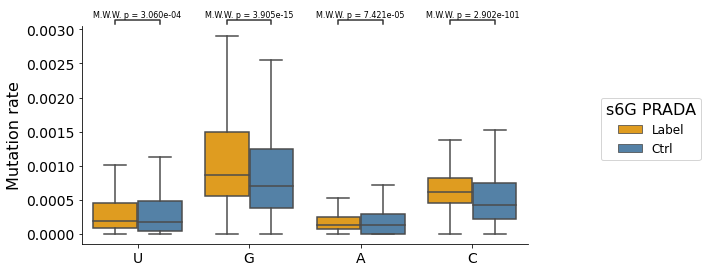

In [4]:
#### plot --- --- 

plt.figure(figsize=(8,4))
order = ['U','G', 'A',  'C']
my_pal = {'Label': "orange", 'Ctrl': "steelblue"}

ax = sns.boxplot(data=dplot, x='Sequence',y='mod_rate', hue='group',showfliers = False,order = order, palette = my_pal)     
plt.title(' ',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Mutation rate',fontsize = 16)
plt.xticks(fontsize = 14) 
plt.yticks(fontsize = 14) 
legend=plt.legend(loc='best', title='s6G PRADA',bbox_to_anchor=(1.15, 0.7),prop={'size': 12})
legend.get_title().set_fontsize('16') 
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data=dplot, x='Sequence',y='mod_rate', hue='group', order=order, 
                    box_pairs = [(("U", 'Label'), ("U", 'Ctrl')),
                                 (("A", 'Label'), ("A", 'Ctrl')),
                                 (("C", 'Label'), ("C", 'Ctrl')),
                                 (("G", 'Label'), ("G", 'Ctrl'))
                                ],
                    test="Mann-Whitney", text_format='full', loc='outside', line_offset_to_box=0.01, verbose=1,fontsize=8)

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig6d_s6G_PRADA_mutrate_label_vs_Ctrl.pdf',bbox_inches='tight', dpi=300) 

print(dplot.groupby(['Sequence','group']).median()[['mod_rate']])  

In [5]:
print(dplot.groupby(['Sequence','group']).mean()[['mod_rate']])  

                mod_rate
Sequence group          
A        Ctrl   0.002589
         Label  0.002115
C        Ctrl   0.001829
         Label  0.002721
G        Ctrl   0.003153
         Label  0.005202
U        Ctrl   0.000490
         Label  0.000845


In [6]:
print(dplot.groupby(["Sequence", "group"]).count())  

                Nucleotide  mod_rate
Sequence group                      
A        Ctrl         2541      2541
         Label        3707      3707
C        Ctrl         2842      2842
         Label        4117      4117
G        Ctrl         1109      1109
         Label        1516      1516
U        Ctrl         2234      2234
         Label        3099      3099


In [ ]:
### 1_2. Extend Fig6e --- --- 

In [8]:
def convert_dot(input_file,rna): 
    sequences=[i for i in SeqIO.parse(open(input_file),'fasta')] 
    
    seq_0 = str(sequences[0].seq)
    length = len(seq_0)
    base = seq_0[0:int(length/2)]
    dot = seq_0[int(length/2):int(length)]
    
    base = list(map(lambda i:i, base))
    dot = list(map(lambda i:i, dot))
    strand = list(map(lambda i: 1 if i == "." else 0, dot))
    Nucleotide = range(1,len(strand)+1)
    
    bench = pd.DataFrame(list(zip(base,dot,strand,Nucleotide)),
              columns=['base','dot','strand','Position2'])
    bench.to_csv('./Data/'+rna+'_base_dot_strand.csv',sep='\t')
    
    return bench 

/tmp/ipykernel_23645/658137782.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp1['region'] = 'SS'
/tmp/ipykernel_23645/658137782.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp2['region'] = 'DS'
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(1605, 8)
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

SS v.s. DS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=5.730e-04 U_stat=1.059e+04
        Nucleotide  Sequence  Modified_effective_depth  \
region                                                   
DS             137       137                       137   
SS             125       125                       125   

        Untreated_effective_depth  Modified_rate  Untreated_rate  \
region                                                             
DS                            137            137             137   
SS                            125            125             125   

        Reactivity_profile  Norm_profile  Position2  base  dot  strand  
region                                                                  
DS                     137           137        137   137  137  

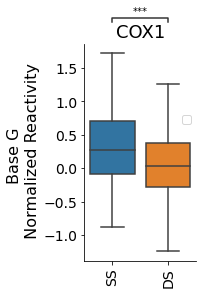

In [9]:
#### normalzied reactivity --- --- 

dir = "./Data/"
s6G_prada = pd.read_csv(dir+"s6G_PRADA_heavy_NC_012920.1_profile.txt",sep='\t')
s6G_prada = s6G_prada[(s6G_prada['Modified_effective_depth'] >=5000) & (s6G_prada['Untreated_effective_depth'] >=5000)]
cox1= s6G_prada[(s6G_prada['Nucleotide']>=5900) & (s6G_prada['Nucleotide']<=7517)]
cox1=cox1[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
print(cox1.shape)
cox1['Nucleotide']=cox1['Nucleotide']-5899 
cox1['Position2'] =cox1['Nucleotide']

dir_bench = './Data/bench/'
bench = convert_dot(dir_bench+'bench_positive_COX1_1_1618_162.dot','COX1')

df = pd.merge(cox1,bench, how='left',on=['Position2','Position2']) 
dplot=df
tmp1 = dplot[dplot['strand'] == 1]
tmp1['region'] = 'SS'
tmp2 = dplot[dplot['strand'] == 0]
tmp2['region'] = 'DS'
dplot = pd.concat([tmp1,tmp2], ignore_index=True)

#### plots Base G --------------------------------

dplott = dplot[(dplot['base'] =='G')]
dplott.to_csv('./Data/'+'source_data_Efig6e.csv',sep=',')

plt.figure(figsize=(2,4))
order = ['SS', 'DS']
ax = sns.boxplot(data=dplott, x='region',y='Norm_profile', showfliers = False,order = order, dodge = False) 
plt.title('COX1',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Base G \n Normalized Reactivity',fontsize = 16)
plt.xticks(fontsize = 14,rotation=90) 
#plt.yticks([-2.0,-1.0, 0.0, 1.0, 2.0],fontsize = 14) 
plt.yticks(fontsize = 14) 
plt.legend(loc='best', bbox_to_anchor=(1.01, 0.7),prop={'size': 12})
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data = dplott, x = dplott['region'], y = dplott['Norm_profile'], order=order, 
                    box_pairs = [('SS','DS')],
                    test="Mann-Whitney", text_format='star', loc='outside', line_offset_to_box=0.1, verbose=3)  

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig6e_s6G_PRADA_baseG_SS_vs_DS.pdf',bbox_inches='tight', dpi=300) 
print(dplott.groupby(["region"]).count())  

In [ ]:
### 1_3. Extend Fig6f --- --- 

(1605, 8)
0.6265109489051094


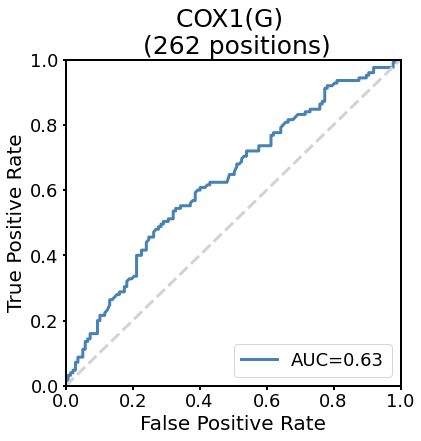

In [10]:
dir = "./Data/"
s6G_prada = pd.read_csv(dir+"s6G_PRADA_heavy_NC_012920.1_profile.txt",sep='\t')
s6G_prada = s6G_prada[(s6G_prada['Modified_effective_depth'] >=5000) & (s6G_prada['Untreated_effective_depth'] >=5000)]
cox1= s6G_prada[(s6G_prada['Nucleotide']>=5900) & (s6G_prada['Nucleotide']<=7517)]
cox1=cox1[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
print(cox1.shape)
cox1['Nucleotide']=cox1['Nucleotide']-5899 
cox1['Position2'] =cox1['Nucleotide']

dir_bench = './Data/bench/'
bench = convert_dot(dir_bench+'bench_positive_COX1_1_1618_162.dot','COX1')

df = pd.merge(cox1,bench, how='left',on=['Position2','Position2']) 

## plot G--------------------------

flt=df[(df['base']=='G')]
flt.to_csv('./Data/'+'source_data_Efig6f.csv',sep=',')

fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile, pos_label=1)
roc_auc_1 = metrics.auc(fpr_1, tpr_1)
print(roc_auc_1)
    
fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
    ax.tick_params(width = 2)
    
plt.title('COX1(G) '+'\n ('+str(flt.shape[0])+' positions)', fontsize = 25)
plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)
plt.legend(loc = 'lower right', fontsize = 18)
plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize = 20)
plt.xlabel('False Positive Rate', fontsize = 20)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig6f_s6G_PRADA_baseG_AUROC.pdf',bbox_inches='tight', dpi=300) 